In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

def load_mat73(file_path):
    """Load MATLAB v7.3 .mat file and return nested dictionary of numpy arrays"""
    data = {}
    with h5py.File(file_path, 'r') as f:
        def extract_data(name, obj):
            if isinstance(obj, h5py.Dataset):
                return np.array(obj)
            return None
        
        def load_group(group, prefix=''):
            result = {}
            for key in group.keys():
                if key != '#refs#':
                    obj = group[key]
                    full_key = f"{prefix}/{key}" if prefix else key
                    if isinstance(obj, h5py.Dataset):
                        result[key] = np.array(obj)
                    elif isinstance(obj, h5py.Group):
                        result[key] = load_group(obj, full_key)
            return result
        
        for key in f.keys():
            if key != '#refs#':
                if isinstance(f[key], h5py.Group):
                    data[key] = load_group(f[key])
                else:
                    data[key] = np.array(f[key])
    
    return data

# Load the data
mat_file_path = 'neuralSPRT/data/dataJ.mat'
data = load_mat73(mat_file_path)

In [3]:
plt.rcParams.update({
        'font.family': 'Arial',
        'axes.labelsize': 10,
        'axes.titlesize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 9,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.linewidth': 0.75,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.major.width': 1.0,
        'ytick.major.width': 1.0,
        'legend.loc': 'upper right'
    })

In [4]:
info = data["info"]

TM = info['TM'].T     # Trial Matrix 27201 x 70
SpM = info['SpM'].T   # Spike Matrix 27201 x 5000 (raw spikes, 1 ms bin)
FM = info['FM'].T     # Boxcar Filter Firing Rate Matrix 27201 x 500 (50 ms boxcar, 10 ms step)
KM = info['KM'].T     # Alpha-Kernel Firing Rate Matrix 27201 x 5000 (alpha-kernel FR, used in the paper)

In [5]:
data = pd.DataFrame(TM)
shape_block = data.iloc[:, 10:30]
mask_bad = shape_block.isin([0, 1]).any(axis=1)
data = data.loc[~mask_bad].reset_index(drop=True)

data = data.rename(columns={
    data.columns[0]: "reward_target",
    data.columns[1]: "saccade_dir",
    data.columns[2]: "rt",
    data.columns[3]: "last_duration",
    data.columns[4]: "target_x_pos",
    data.columns[5]: "target_y_pos",
    data.columns[6]: "RF_side",
    data.columns[7]: "TinOrTout",
    data.columns[8]: "target_color",
    data.columns[9]: "chosen_target_color",
})

In [6]:
logLR_table = np.array([np.inf, -np.inf, 0.9, -0.9, 0.7, -0.7, 0.5, -0.5, 0.3, -0.3])

shape_block = data.iloc[:, 10:30]
shape_vals = shape_block.to_numpy()
valid_mask = ~np.isnan(shape_vals)
cum_loglr = np.zeros(shape_vals.shape[0])
nums_shape = np.sum(valid_mask, axis=1)  # Count of non-NaN shapes per trial

for i in range(shape_vals.shape[0]):
    ids = shape_vals[i, valid_mask[i]].astype(int)
    cum_loglr[i] = np.sum(logLR_table[ids])

data["cum_loglr"] = cum_loglr
data["nums_shape"] = nums_shape
data

,reward_target,saccade_dir,rt,last_duration,target_x_pos,target_y_pos,RF_side,TinOrTout,target_color,chosen_target_color,...,62,63,64,65,66,67,68,69,cum_loglr,nums_shape
0,1.0,1.0,644.0,105.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.1,3
1,2.0,2.0,905.0,95.0,-4.0,-74.0,2.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,4
2,1.0,1.0,648.0,108.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.3,3
3,2.0,1.0,163.0,163.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,1
4,2.0,1.0,456.0,187.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17914,1.0,1.0,466.0,197.0,39.0,77.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6,2
17915,1.0,2.0,631.0,93.0,-39.0,-77.0,2.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.7,3
17916,2.0,2.0,419.0,150.0,39.0,77.0,2.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,2
17917,2.0,2.0,1243.0,168.0,39.0,77.0,2.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.7,5


/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_14888/943960993.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([saccade_col, "rt_bin"])[y_col]
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_14888/943960993.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df.groupby([saccade_col, "rt_bin"])[y_col].count().reset_index(name='count')


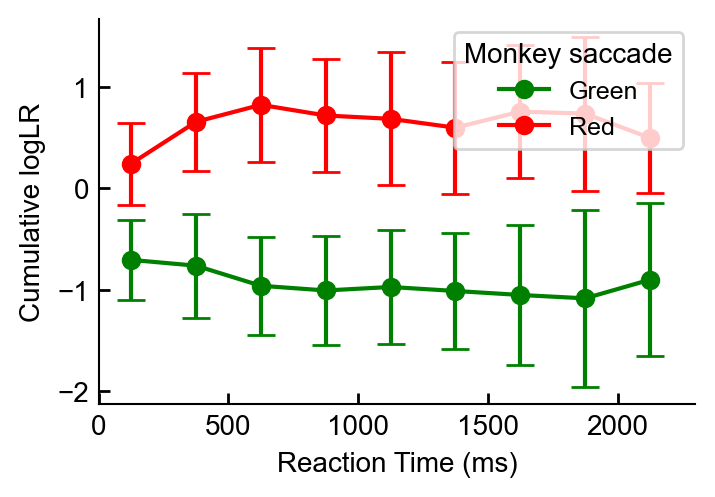

In [7]:
df = data.copy()
reward_col = df.columns[8]
saccade_col = df.columns[9]
rt_col = df.columns[2]
y_col = df.columns[-2]

df = df[df[reward_col] == df[saccade_col]]

rt_min = df[rt_col].min()
rt_max = df[rt_col].max()
bins = np.arange(np.floor(rt_min/100)*100, np.ceil(rt_max/100)*100 + 100, 250)

df["rt_bin"] = pd.cut(df[rt_col], bins=bins)

agg = (
    df.groupby([saccade_col, "rt_bin"])[y_col]
      .agg(["mean", "std"])       
      .reset_index()
)

agg["rt_center"] = agg["rt_bin"].apply(lambda x: x.mid)
bin_counts = df.groupby([saccade_col, "rt_bin"])[y_col].count().reset_index(name='count')
agg = agg.merge(bin_counts, on=[saccade_col, "rt_bin"])
agg = agg[agg['count'] > 17].reset_index(drop=True)
# agg = agg[agg[''] > 10].reset_index(drop=True)


# ---- plot ----
plt.figure(figsize=(3.85, 2.5))

colors = ["green", "red"]

for direction, label in [(1, "Green"), (2, "Red")]:
    sub = agg[agg[saccade_col] == direction].sort_values("rt_center")

    plt.plot(sub["rt_center"], sub["mean"], marker="o", label=label, color=colors[direction-1])
    plt.errorbar(
        sub["rt_center"],
        sub["mean"],
        yerr=sub["std"],
        fmt="none",
        capsize=5,
        color=colors[direction-1]
    )

plt.xlabel("Reaction Time (ms)")
plt.xlim(0, 2300)
plt.ylabel("Cumulative logLR")
# plt.title("Correct trials — mean ± std per RT bin")
plt.legend(title="Monkey saccade")
plt.show()

In [7]:
agg

,chosen_target_color,rt_bin,mean,std,rt_center,count
0,1.0,"(0.0, 250.0]",-0.705263,0.390519,125.0,76
1,1.0,"(250.0, 500.0]",-0.762216,0.512009,375.0,1408
2,1.0,"(500.0, 750.0]",-0.959874,0.481485,625.0,1266
3,1.0,"(750.0, 1000.0]",-1.006032,0.534705,875.0,630
4,1.0,"(1000.0, 1250.0]",-0.971838,0.557609,1125.0,419
5,1.0,"(1250.0, 1500.0]",-1.011111,0.575207,1375.0,234
6,1.0,"(1500.0, 1750.0]",-1.050376,0.686187,1625.0,133
7,1.0,"(1750.0, 2000.0]",-1.083582,0.867703,1875.0,67
8,1.0,"(2000.0, 2250.0]",-0.900000,0.753371,2125.0,38
9,2.0,"(0.0, 250.0]",0.241704,0.403153,125.0,223


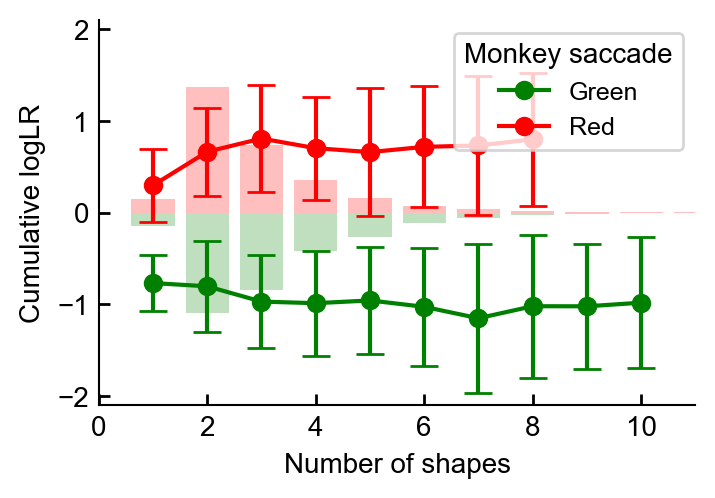

In [8]:
df = data.copy()

reward_col = df.columns[8]
saccade_col = df.columns[9]

# keep only correct trials
df = df[df[reward_col] == df[saccade_col]].copy()

x_col = "nums_shape"
y_col = "cum_loglr"

df = df[np.isfinite(df[y_col])].copy()
agg = (
    df.groupby([saccade_col, x_col])[y_col]
      .agg(["mean", "std", "count"])
      .reset_index()
)

# Frequency of nums_shape at decision: split by cum_loglr > 0 (above) vs < 0 (below)
freq_pos = df[df[y_col] > 0].groupby(x_col, observed=True).size().reindex(range(1, 15)).fillna(0).astype(int)
freq_neg = df[df[y_col] < 0].groupby(x_col, observed=True).size().reindex(range(1, 15)).fillna(0).astype(int)
max_freq = max(freq_pos.max(), freq_neg.max(), 1)
y_range = max(agg["mean"].max() - agg["mean"].min(), 0.5)
scale = 0.7 * y_range / max_freq

agg = agg[agg["count"] > 10].copy()
agg = agg[agg["nums_shape"] <= 10].copy()

# ---- plot ----
plt.figure(figsize=(3.85, 2.5))
colors = {1: "green", 2: "red"}

for direction, label in [(1, "Green"), (2, "Red")]:
    sub = agg[agg[saccade_col] == direction].sort_values(x_col)

    plt.plot(sub[x_col], sub["mean"], marker="o", label=label, color=colors[direction])
    plt.errorbar(
        sub[x_col],
        sub["mean"],
        yerr=sub["std"],
        fmt="none",
        capsize=5,
        color=colors[direction]
    )

plt.bar(freq_pos.index, freq_pos.values * scale, width=0.8, bottom=0, color="red", alpha=0.25)
plt.bar(freq_neg.index, -freq_neg.values * scale, width=0.8, bottom=0, color="green", alpha=0.25)
plt.xlim(0, 11)
plt.ylim(-2.1, 2.1)

plt.xlabel("Number of shapes")
plt.ylabel("Cumulative logLR")
# plt.title("Correct trials — cum_loglr by number of shapes (mean ± std)")
plt.legend(title="Monkey saccade")
plt.show()

In [9]:
import statsmodels.formula.api as smf

left = data[data["target_color"] == 1]
right = data[data["target_color"] == 2]

left["nums_shape"] = left["nums_shape"].astype("category")
right["nums_shape"] = right["nums_shape"].astype("category")

model1 = smf.ols(
    "cum_loglr ~ C(nums_shape)",
    data=left
).fit(cov_type="HC3")

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              cum_loglr   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     16.52
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           5.42e-30
Time:                        16:47:11   Log-Likelihood:                -12304.
No. Observations:                8896   AIC:                         2.463e+04
Df Residuals:                    8885   BIC:                         2.471e+04
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.1832    

/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_14888/2345429840.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  left["nums_shape"] = left["nums_shape"].astype("category")
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_14888/2345429840.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  right["nums_shape"] = right["nums_shape"].astype("category")


In [10]:
import numpy as np
from scipy import stats

def calculate_large_sample_stats(group1, group2):
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    # 1. Cohen's d (Effect Size)
    # Pooled standard deviation for different sample sizes
    s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    cohens_d = (mean1 - mean2) / s_pooled

    # 2. 95% Confidence Interval for the difference in means
    se_diff = np.sqrt(var1/n1 + var2/n2)
    df = n1 + n2 - 2
    t_crit = stats.t.ppf(0.975, df)
    mean_diff = mean1 - mean2
    ci_lower = mean_diff - t_crit * se_diff
    ci_upper = mean_diff + t_crit * se_diff

    # 3. Bayes Factor (Approximate BF10 using the BIC method)
    # This estimates how much more likely the data is under H1 vs H0
    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
    # Schwarz (1978) approximation for large n
    bf10 = np.exp((t_stat**2 - np.log(n1 + n2)) / 2)

    return {
        "Cohen's d": cohens_d,
        "Mean Diff": mean_diff,
        "95% CI": (ci_lower, ci_upper),
        "T-statistic": t_stat,
        "P-value": p_val,
        "Bayes Factor (BF10)": bf10
    }

# Example Usage with large N
np.random.seed(2026) 
s1 = np.random.normal(loc=10.0, scale=1.0, size=1500)
s2 = np.random.normal(loc=10.1, scale=1.0, size=1200)

results = calculate_large_sample_stats(s1, s2)

for key, value in results.items():
    print(f"{key}: {value}")

Cohen's d: -0.0940589777848424
Mean Diff: -0.09735159366481483
95% CI: (np.float64(-0.17581927190683577), np.float64(-0.018883915422793884))
T-statistic: -2.432737374438172
P-value: 0.0150525590784902
Bayes Factor (BF10): 0.3710576047714083


In [11]:
model2 = smf.ols(
    "cum_loglr ~ C(nums_shape)",
    data=right
).fit(cov_type="HC3")

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              cum_loglr   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     19.50
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           4.61e-36
Time:                        23:45:27   Log-Likelihood:                -12337.
No. Observations:                9023   AIC:                         2.470e+04
Df Residuals:                    9012   BIC:                         2.477e+04
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.0500    

In [16]:
agg

,chosen_target_color,nums_shape,mean,std,count
0,1.0,1,-0.767901,0.301684,162
1,1.0,2,-0.803378,0.496056,1658
2,1.0,3,-0.970137,0.508875,1172
3,1.0,4,-0.987521,0.570758,609
4,1.0,5,-0.957627,0.581159,354
5,1.0,6,-1.027059,0.642828,170
6,1.0,7,-1.151613,0.812887,93
7,1.0,8,-1.020513,0.779737,39
8,1.0,9,-1.021429,0.680608,28
9,1.0,10,-0.981818,0.718078,11


In [19]:
left_data

,reward_target,saccade_dir,rt,last_duration,target_x_pos,target_y_pos,RF_side,TinOrTout,target_color,chosen_target_color,...,62,63,64,65,66,67,68,69,cum_loglr,nums_shape
1,2.0,2.0,905.0,95.0,-4.0,-74.0,2.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,4
5,2.0,1.0,1009.0,201.0,-4.0,-74.0,2.0,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.8,4
7,2.0,2.0,604.0,64.0,-4.0,-74.0,2.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7,3
9,1.0,2.0,590.0,50.0,-4.0,-74.0,2.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9,3
10,2.0,2.0,753.0,214.0,-4.0,-74.0,2.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17907,1.0,1.0,468.0,199.0,-39.0,-77.0,2.0,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.6,2
17908,1.0,2.0,517.0,249.0,-39.0,-77.0,2.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,2
17911,1.0,1.0,586.0,48.0,-39.0,-77.0,2.0,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.1,3
17913,1.0,1.0,498.0,229.0,-39.0,-77.0,2.0,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,2


In [22]:
from scipy.stats import ttest_ind

left_data = data[(data["target_color"] == 1) & (data["target_color"] == data["chosen_target_color"])]
right_data = data[(data["target_color"] == 2) & (data["target_color"] == data["chosen_target_color"])]

cum_loglr_1 = left_data.loc[left_data["nums_shape"] == 1, "cum_loglr"].dropna()
cum_loglr_2 = left_data.loc[left_data["nums_shape"] == 2, "cum_loglr"].dropna()
cum_loglr_3 = left_data.loc[left_data["nums_shape"] == 3, "cum_loglr"].dropna()
t_stat_1_2, p_val_1_2 = ttest_ind(cum_loglr_1, cum_loglr_2, equal_var=False)

results = calculate_large_sample_stats(cum_loglr_1, cum_loglr_2)
print(results)

# Calculate Cohen's d for effect size (unbiased pooled sd)
n1, n2 = len(cum_loglr_1), len(cum_loglr_2)
s1, s2 = cum_loglr_1.std(ddof=1), cum_loglr_2.std(ddof=1)
pooled_sd = (( (n1 - 1)*s1**2 + (n2 - 1)*s2**2 ) / (n1 + n2 - 2)) ** 0.5
cohens_d_1_2 = (cum_loglr_1.mean() - cum_loglr_2.mean()) / pooled_sd

print(f"T-test between nums_shape=1 and nums_shape=2: t={t_stat_1_2:.4f}, p={p_val_1_2:.4e}, Cohen's d={cohens_d_1_2:.4f}")

{"Cohen's d": np.float64(0.07359980295126495), 'Mean Diff': np.float64(0.03547632876141105), '95% CI': (np.float64(-0.016791537498864972), np.float64(0.08774419502168707)), 'T-statistic': np.float64(1.3311936052758964), 'P-value': np.float64(0.18431158106036058), 'Bayes Factor (BF10)': np.float64(0.05685462642031221)}
T-test between nums_shape=1 and nums_shape=2: t=1.3312, p=1.8431e-01, Cohen's d=0.0736


In [23]:

t_stat_2_3, p_val_2_3 = ttest_ind(cum_loglr_2, cum_loglr_3, equal_var=False)

results = calculate_large_sample_stats(cum_loglr_2, cum_loglr_3)
print(results)

# Calculate Cohen's d for effect size between nums_shape=2 and 3
n2b, n3 = len(cum_loglr_2), len(cum_loglr_3)
s2b, s3 = cum_loglr_2.std(ddof=1), cum_loglr_3.std(ddof=1)
pooled_sd_2_3 = (( (n2b - 1)*s2b**2 + (n3 - 1)*s3**2 ) / (n2b + n3 - 2)) ** 0.5
cohens_d_2_3 = (cum_loglr_2.mean() - cum_loglr_3.mean()) / pooled_sd_2_3

print(f"T-test between nums_shape=2 and nums_shape=3: t={t_stat_2_3:.4f}, p={p_val_2_3:.4e}, Cohen's d={cohens_d_2_3:.4f}")

{"Cohen's d": np.float64(0.3325840670804539), 'Mean Diff': np.float64(0.16675895544201869), '95% CI': (np.float64(0.12907452534788852), np.float64(0.20444338553614885)), 'T-statistic': np.float64(8.676832600955061), 'P-value': np.float64(7.229371746204057e-18), 'Bayes Factor (BF10)': np.float64(419336995244251.4)}
T-test between nums_shape=2 and nums_shape=3: t=8.6768, p=7.2294e-18, Cohen's d=0.3326


In [31]:
cum_loglr_1 = right_data.loc[right_data["nums_shape"] == 1, "cum_loglr"].dropna()
cum_loglr_2 = right_data.loc[right_data["nums_shape"] == 2, "cum_loglr"].dropna()
t_stat_1_2, p_val_1_2 = ttest_ind(cum_loglr_1, cum_loglr_2, equal_var=False)
# Calculate Cohen's d for effect size
n1, n2 = len(cum_loglr_1), len(cum_loglr_2)
s1, s2 = cum_loglr_1.std(ddof=1), cum_loglr_2.std(ddof=1)
pooled_sd = (( (n1 - 1) * s1**2 + (n2 - 1) * s2**2 ) / (n1 + n2 - 2)) ** 0.5
cohens_d_1_2 = (cum_loglr_1.mean() - cum_loglr_2.mean()) / pooled_sd
print(f"T-test between nums_shape=1 and nums_shape=2: t={t_stat_1_2:.4f}, p={p_val_1_2:.4e}, Cohen's d={cohens_d_1_2:.4f}")

cum_loglr_3 = right_data.loc[right_data["nums_shape"] == 3, "cum_loglr"].dropna()
t_stat_2_3, p_val_2_3 = ttest_ind(cum_loglr_2, cum_loglr_3, equal_var=False)
# Calculate Cohen's d for effect size
n2b, n3 = len(cum_loglr_2), len(cum_loglr_3)
s2b, s3 = cum_loglr_2.std(ddof=1), cum_loglr_3.std(ddof=1)
pooled_sd_2_3 = (( (n2b - 1) * s2b**2 + (n3 - 1) * s3**2 ) / (n2b + n3 - 2)) ** 0.5
cohens_d_2_3 = (cum_loglr_2.mean() - cum_loglr_3.mean()) / pooled_sd_2_3
print(f"T-test between nums_shape=2 and nums_shape=3: t={t_stat_2_3:.4f}, p={p_val_2_3:.4e}, Cohen's d={cohens_d_2_3:.4f}")

T-test between nums_shape=1 and nums_shape=2: t=-4.2053, p=3.0172e-05, Cohen's d=-0.1678
T-test between nums_shape=2 and nums_shape=3: t=7.9302, p=2.7539e-15, Cohen's d=0.2142


In [30]:
cum_loglr_5 = left_data.loc[left_data["nums_shape"] == 3, "cum_loglr"].dropna()
cum_loglr_6 = left_data.loc[left_data["nums_shape"] == 4, "cum_loglr"].dropna()
t_stat_5_6, p_val_5_6 = ttest_ind(cum_loglr_5, cum_loglr_6, equal_var=False)
print(f"T-test between nums_shape=5 and nums_shape=6: t={t_stat_5_6:.4f}, p={p_val_5_6:.4e}")

T-test between nums_shape=5 and nums_shape=6: t=2.7974, p=5.1943e-03


In [25]:
data

,reward_target,saccade_dir,rt,last_duration,target_x_pos,target_y_pos,RF_side,TinOrTout,target_color,chosen_target_color,...,63,64,65,66,67,68,69,cum_loglr,nums_shape,decision_fr
0,1.0,1.0,644.0,105.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.1,3,100.0
1,2.0,2.0,905.0,95.0,-4.0,-74.0,2.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,4,20.0
2,1.0,1.0,648.0,108.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.3,3,80.0
3,2.0,1.0,163.0,163.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,1,80.0
4,2.0,1.0,456.0,187.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17914,1.0,1.0,466.0,197.0,39.0,77.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6,2,0.0
17915,1.0,2.0,631.0,93.0,-39.0,-77.0,2.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.7,3,0.0
17916,2.0,2.0,419.0,150.0,39.0,77.0,2.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,2,60.0
17917,2.0,2.0,1243.0,168.0,39.0,77.0,2.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.7,5,40.0


/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10683/3120601263.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("loglr_bin")["is_right"]


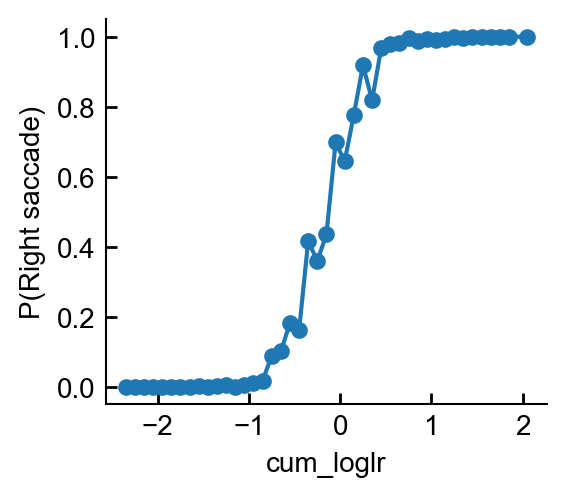

In [8]:
df = data.copy()
df["is_right"] = (df["chosen_target_color"] == 2).astype(int)

# ---- build bins ----
x = df["cum_loglr"]
bins = np.arange(
    np.floor(x.min()/0.1)*0.1,
    np.ceil(x.max()/0.1)*0.1 + 0.1,
    0.1
)

df["loglr_bin"] = pd.cut(x, bins=bins)

agg = (
    df.groupby("loglr_bin")["is_right"]
      .agg(["mean", "std", "count"])
      .reset_index()
)

agg["center"] = agg["loglr_bin"].apply(lambda x: x.mid)

# filter sparse bins
agg = agg[agg["count"] > 10]

# ---- plot ----
plt.figure(figsize=(2.85, 2.5))

plt.plot(agg["center"], agg["mean"], marker="o", markersize=5)

plt.xlabel("cum_loglr")
plt.ylabel("P(Right saccade)")
# plt.title("Psychometric curve: P(Right) vs cumulative logLR")
# plt.xlim(-3.0, 3.0)
plt.ylim(-0.05, 1.05)
plt.show()

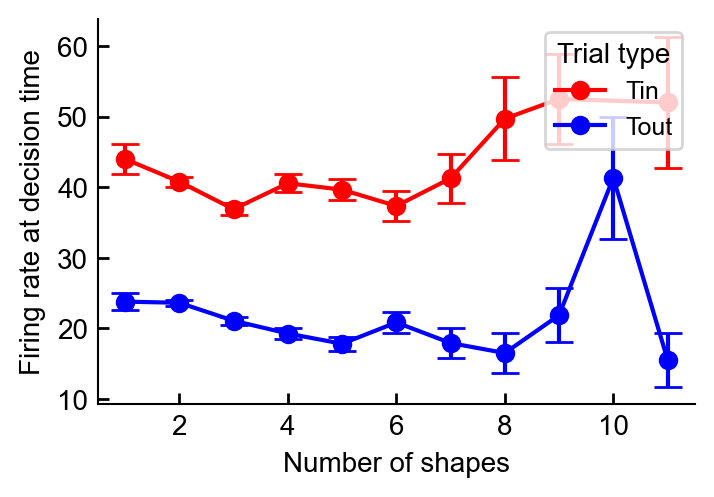

In [9]:
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
FM_aligned = FM[~mask_bad_fr.values] 

decision_fr = []
for i in range(len(data)):
    n = int(data.iloc[i]["nums_shape"])
    if 1 <= n <= 20:
        col_idx = n * 25 - 1
        fr = FM_aligned[i, col_idx]
        decision_fr.append(fr)
    else:
        decision_fr.append(np.nan)

data["decision_fr"] = decision_fr

df_fr = data.dropna(subset=["decision_fr"]).copy()
# df_fr = df_fr[df_fr['target_color'] == df_fr['chosen_target_color']]
df_fr = df_fr[df_fr["TinOrTout"].notna()].copy()
agg_fr = (
    df_fr.groupby(["nums_shape", "TinOrTout"], observed=True)["decision_fr"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
agg_fr = agg_fr[agg_fr["count"] > 10]
agg_fr["sem"] = agg_fr["std"] / np.sqrt(agg_fr["count"])  # standard error of the mean

plt.figure(figsize=(3.85, 2.5))
colors = {1.0: "red", 2.0: "blue"}
labels = {1.0: "Tin", 2.0: "Tout"}

for tinout_val in [1.0, 2.0]:
    sub = agg_fr[agg_fr["TinOrTout"] == tinout_val].sort_values("nums_shape")
    if len(sub) == 0:
        continue
    plt.plot(
        sub["nums_shape"],
        sub["mean"],
        marker="o",
        label=labels.get(tinout_val, str(tinout_val)),
        color=colors.get(tinout_val, "gray"),
    )
    plt.errorbar(
        sub["nums_shape"],
        sub["mean"],
        yerr=sub["sem"],
        fmt="none",
        capsize=5,
        color=colors.get(tinout_val, "gray"),
    )

plt.xlabel("Number of shapes")
plt.ylabel("Firing rate at decision time")
# plt.title("Firing rate at decision vs. nums_shape (Tin vs Tout)")
plt.legend(title="Trial type")
plt.show()

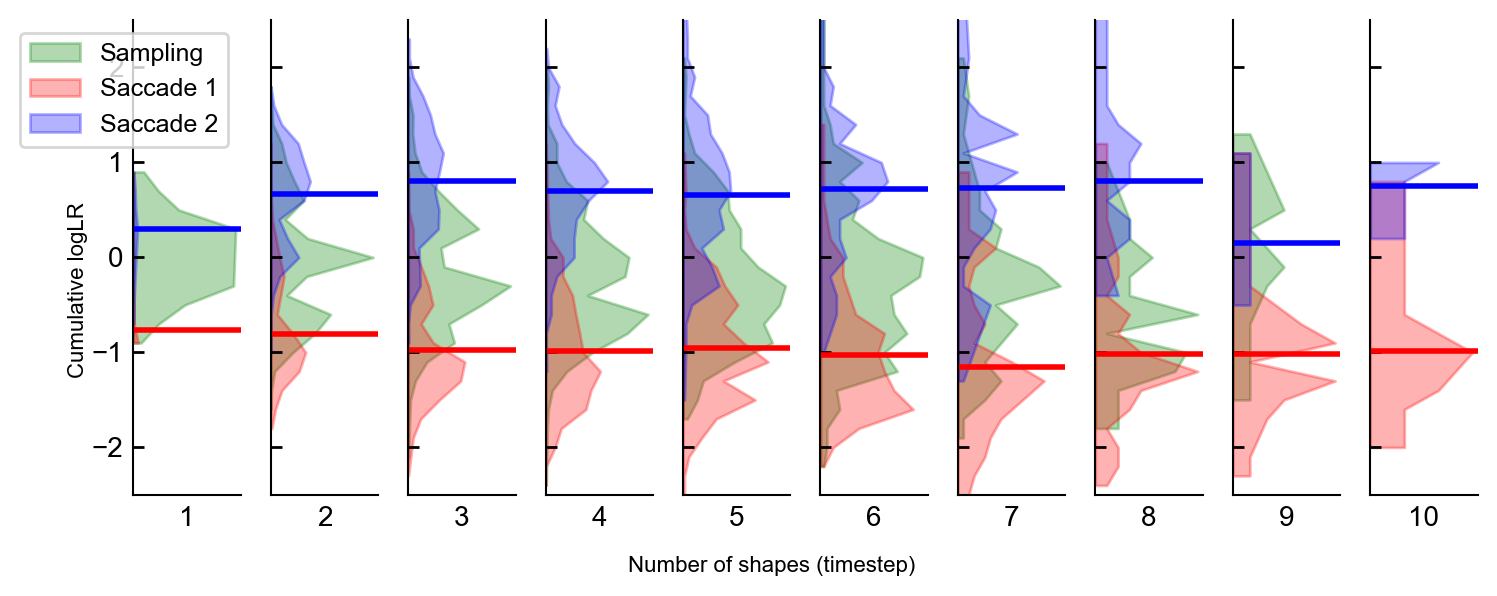

In [14]:
def plot_decision_threshold_distribution_monkey(
    df,
    logLR_table,
    nums_shape_col="nums_shape",
    cum_loglr_col="cum_loglr",
    saccade_col=9,
    shape_block_cols=(10, 30),
    max_timestep=15,
    figsize=(5, 3),
    ylim=(-3.2, 3.2),
    savePNG=False,
    saveSVG=False,
    save_path=None,
):
    """
    Plot cumulative logLR distribution by timestep.
    - Sampling (green): trials still viewing shapes before decision (t < nums_shape).
    - Action (red/blue): trials that decided at t (saccade 1 or 2).
    """
    df = df.dropna(subset=[nums_shape_col, cum_loglr_col]).copy()
    df = df[(df[nums_shape_col] >= 1) & (df[nums_shape_col] <= max_timestep)]

    shape_block = df.iloc[:, shape_block_cols[0] : shape_block_cols[1]]
    shape_vals = shape_block.to_numpy()
    valid_mask = ~np.isnan(shape_vals)

    def partial_cumloglr(i, t):
        ids = shape_vals[i, valid_mask[i]].astype(int)[:t]
        return np.sum(logLR_table[ids])

    rows = []
    for i in range(len(df)):
        n = int(df.iloc[i][nums_shape_col])
        for t in range(1, min(n, max_timestep) + 1):
            if t < n:
                action_type = "sampling"
                ev = partial_cumloglr(i, t)
            else:
                action_type = df.iloc[i, saccade_col] if isinstance(saccade_col, int) else df.iloc[i][saccade_col]
                ev = df.iloc[i][cum_loglr_col]
            if np.isfinite(ev):
                rows.append({"t": t, "action": action_type, "evidence": ev})
    plot_df = pd.DataFrame(rows)
    if plot_df.empty:
        plt.text(0.5, 0.5, "No valid data", ha="center", va="center")
        plt.show()
        return

    fig, axes = plt.subplots(1, max_timestep, figsize=figsize, sharey=True)
    if max_timestep == 1:
        axes = [axes]

    colors = {"sampling": "green", 1.0: "red", 2.0: "blue", 1: "red", 2: "blue"}
    labels = {"sampling": "Sampling", 1.0: "Saccade 1", 2.0: "Saccade 2", 1: "Saccade 1", 2: "Saccade 2"}

    for t in range(max_timestep):
        ax = axes[t]
        timestep_data = plot_df[plot_df["t"] == t + 1]

        for action in ["sampling", 1.0, 2.0]:
            if action == "sampling":
                action_data = timestep_data[timestep_data["action"] == "sampling"]
            else:
                action_data = timestep_data[timestep_data["action"].isin([action, int(action)])]
            if action_data.empty:
                continue

            ev = action_data["evidence"].round(10).to_numpy()
            uniq_vals, counts = np.unique(ev, return_counts=True)

            ax.fill_betweenx(
                uniq_vals, 0, counts,
                color=colors[action], alpha=0.3,
                label=labels.get(action, str(action)) if t == 0 else None,
            )
            if action != "sampling":
                mean_ev = action_data["evidence"].mean()
                ax.axhline(mean_ev, color=colors[action], linewidth=2)

        ax.set_xlabel(str(t + 1))
        ax.set_xlim(0, None)
        ax.set_ylim(ylim)

    fig.text(0.54, 0.03, "Number of shapes (timestep)", ha="center", fontsize=8)
    fig.text(0.1, 0.5, "Cumulative logLR", va="center", rotation="vertical", fontsize=8)

    for ax in axes:
        ax.set_xticks([])
        ax.label_outer()

    axes[0].legend(loc="best")
    plt.tight_layout(rect=[0.05, 0.05, 1, 1])

    if savePNG and save_path:
        plt.savefig(save_path + "decision_threshold_distribution.png", dpi=300)
    if saveSVG and save_path:
        plt.savefig(save_path + "decision_threshold_distribution.svg", dpi=300)

    plt.show()

logLR_table = np.array([np.inf, -np.inf, 0.9, -0.9, 0.7, -0.7, 0.5, -0.5, 0.3, -0.3])
correct_data = data[data["target_color"] == data["chosen_target_color"]]
plot_decision_threshold_distribution_monkey(
    correct_data,
    logLR_table,
    saccade_col=9,
    max_timestep=10,
    figsize=(8, 3),
    ylim=(-2.5, 2.5),
)

In [10]:
data

,reward_target,saccade_dir,rt,last_duration,target_x_pos,target_y_pos,RF_side,TinOrTout,target_color,chosen_target_color,...,62,63,64,65,66,67,68,69,cum_loglr,nums_shape
0,1.0,1.0,644.0,105.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.1,3
1,2.0,2.0,905.0,95.0,-4.0,-74.0,2.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,4
2,1.0,1.0,648.0,108.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.3,3
3,2.0,1.0,163.0,163.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,1
4,2.0,1.0,456.0,187.0,4.0,74.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17914,1.0,1.0,466.0,197.0,39.0,77.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6,2
17915,1.0,2.0,631.0,93.0,-39.0,-77.0,2.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.7,3
17916,2.0,2.0,419.0,150.0,39.0,77.0,2.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,2
17917,2.0,2.0,1243.0,168.0,39.0,77.0,2.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.7,5


/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10683/4185647670.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = cm.get_cmap("Reds")(np.linspace(0.35, 0.95, 8))
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10683/4185647670.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap("Blues")(np.linspace(0.35, 0.95, 8))


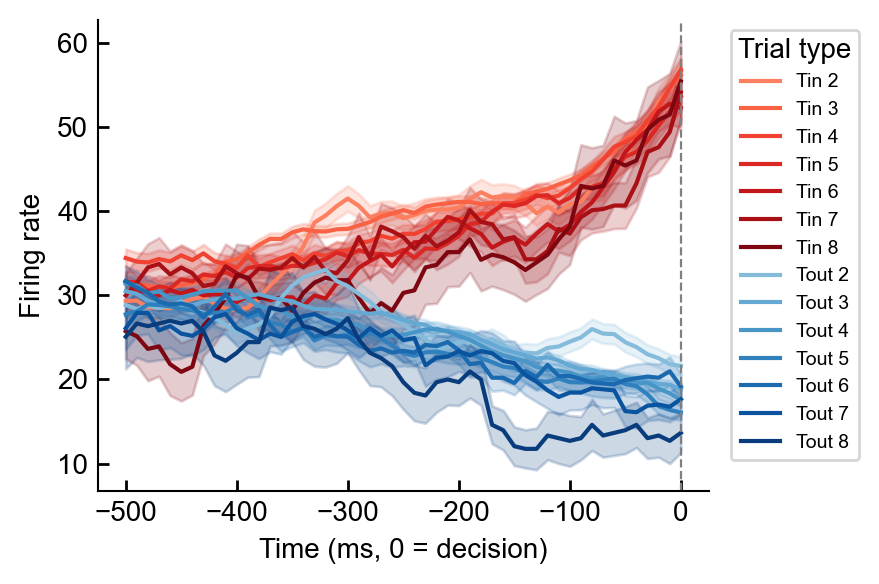

In [11]:
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
FM_aligned = FM[~mask_bad_fr.values]

n_pre = 50  # 400ms before decision
window_bins = n_pre + 1  # include decision
time_ms = np.arange(-n_pre * 10, 1, 10)  # -400, -390, ..., 0 ms (41 points)

# Extract rt-aligned traces for each trial
traces = []
valid_rt = []
for i in range(len(data)):
    rt_ms = data.iloc[i]["rt"]
    col_at_rt = int(rt_ms / 10)
    col_start = col_at_rt - n_pre
    if col_start < 0:
        valid_rt.append(False)
        traces.append(np.full(window_bins, np.nan))
        continue
    valid_rt.append(True)
    col_end = col_at_rt + 1
    traces.append(FM_aligned[i, col_start:col_end])

data["rt_aligned_trace"] = traces
data["rt_aligned_valid"] = valid_rt

# Filter valid trials (rt >= 400ms for full window)
df_rt = data[data["rt_aligned_valid"]].copy()
df_rt = df_rt.dropna(subset=["TinOrTout", "nums_shape"]).copy()
df_rt = df_rt[(df_rt["nums_shape"] >= 1) & (df_rt["nums_shape"] <= 8)].copy()
# df_rt = df_rt[df_rt["target_color"] == df_rt["chosen_target_color"]].copy()

# Bin nums_shape for gradient (5 levels to keep legend readable)
df_rt["nums_bin"] = pd.cut(df_rt["nums_shape"], bins=[0, 1, 2, 3, 4, 5, 6, 7, 8], labels=["1", "2", "3", "4", "5", "6", "7", "8"])
df_rt = df_rt.dropna(subset=["nums_bin"]).copy()

# Gradient colors by nums_bin: Reds for Tin, Blues for Tout
import matplotlib.cm as cm
bin_labels = ["1", "2", "3", "4", "5", "6", "7", "8"]
reds = cm.get_cmap("Reds")(np.linspace(0.35, 0.95, 8))
blues = cm.get_cmap("Blues")(np.linspace(0.35, 0.95, 8))
color_map = {("Tin", b): reds[i] for i, b in enumerate(bin_labels)}
color_map.update({("Tout", b): blues[i] for i, b in enumerate(bin_labels)})

plt.figure(figsize=(4.5, 3))
for tinout_val, label in [(1.0, "Tin"), (2.0, "Tout")]:
    sub = df_rt[df_rt["TinOrTout"] == tinout_val]
    for nb in bin_labels:
        sub_n = sub[sub["nums_bin"] == nb]
        if len(sub_n) < 5:
            continue
        mean_trace = np.nanmean(np.stack(sub_n["rt_aligned_trace"].values), axis=0)
        sem_trace = np.nanstd(np.stack(sub_n["rt_aligned_trace"].values), axis=0) / np.sqrt(len(sub_n))
        c = color_map[(label, nb)]
        plt.plot(time_ms, mean_trace, color=c, label=f"{label} {nb}")
        plt.fill_between(time_ms, mean_trace - sem_trace, mean_trace + sem_trace, color=c, alpha=0.2)

plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Time (ms, 0 = decision)")
plt.ylabel("Firing rate")
plt.legend(title="Trial type", fontsize=7, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10683/773168727.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10683/773168727.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))


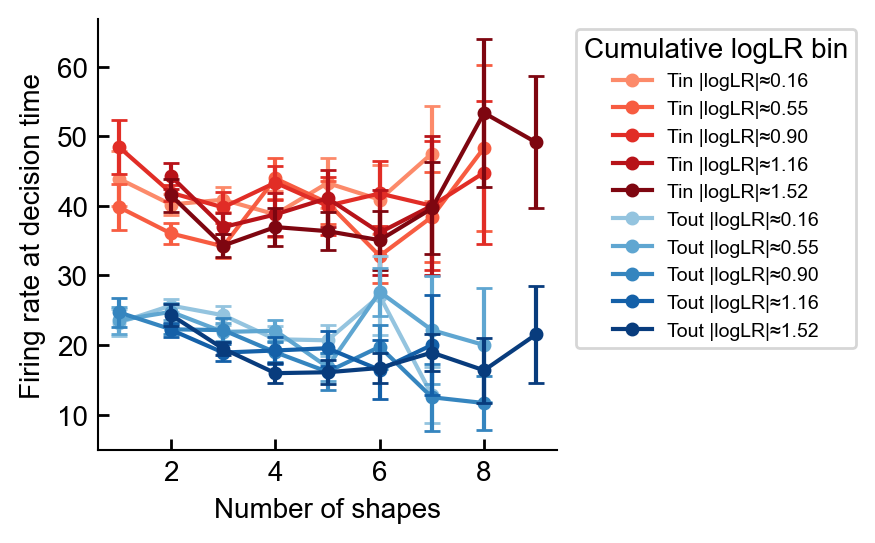

In [12]:
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
FM_aligned = FM[~mask_bad_fr.values] 

decision_fr = []
for i in range(len(data)):
    n = int(data.iloc[i]["nums_shape"])
    if 1 <= n <= 20:
        col_idx = n * 25 - 1
        fr = FM_aligned[i, col_idx]
        decision_fr.append(fr)
    else:
        decision_fr.append(np.nan)

data["decision_fr"] = decision_fr

df_fr = data.dropna(subset=["decision_fr", "cum_loglr"]).copy()
df_fr = df_fr[df_fr["TinOrTout"].notna()].copy()
df_fr = df_fr[np.isfinite(df_fr["cum_loglr"])].copy()

# Group by (nums_shape, TinOrTout, cum_loglr_bin) for gradient by |cumulative logLR|
n_bins = 5
df_fr["abs_cum_loglr"] = np.abs(df_fr["cum_loglr"])
df_fr["cum_loglr_bin"] = pd.qcut(df_fr["abs_cum_loglr"], q=n_bins, duplicates="drop")
bin_centers = df_fr.groupby("cum_loglr_bin", observed=True)["abs_cum_loglr"].mean().sort_values()

agg_fr = (
    df_fr.groupby(["nums_shape", "TinOrTout", "cum_loglr_bin"], observed=True)["decision_fr"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
agg_fr = agg_fr[agg_fr["count"] > 10]
agg_fr["sem"] = agg_fr["std"] / np.sqrt(agg_fr["count"])

# Gradient colors: Reds for Tin, Blues for Tout
import matplotlib.cm as cm
reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))

plt.figure(figsize=(4.5, 2.8))
for tinout_val, cmap_colors in [(1.0, reds), (2.0, blues)]:
    sub_all = agg_fr[agg_fr["TinOrTout"] == tinout_val]
    bins_seen = sub_all["cum_loglr_bin"].unique()
    bin_order = sorted(bins_seen, key=lambda b: bin_centers.get(b, 0) if b in bin_centers.index else 0)
    for idx, bin_val in enumerate(bin_order):
        sub = sub_all[sub_all["cum_loglr_bin"] == bin_val].sort_values("nums_shape")
        if len(sub) < 2:
            continue
        c = cmap_colors[min(idx, len(cmap_colors) - 1)]
        lr_mid = bin_centers.get(bin_val, float("nan"))
        label = f"{'Tin' if tinout_val == 1.0 else 'Tout'} |logLR|≈{lr_mid:.2f}"
        plt.plot(
            sub["nums_shape"],
            sub["mean"],
            marker="o",
            markersize=4,
            color=c,
            label=label,
        )
        plt.errorbar(
            sub["nums_shape"],
            sub["mean"],
            yerr=sub["sem"],
            fmt="none",
            capsize=3,
            color=c,
        )

plt.xlabel("Number of shapes")
plt.ylabel("Firing rate at decision time")
plt.legend(title="Cumulative logLR bin", fontsize=7, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10683/3227902504.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = cm.get_cmap("Reds")(np.linspace(0.45, 0.9, len(levels)))
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10683/3227902504.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap("Blues")(np.linspace(0.45, 0.9, len(levels)))


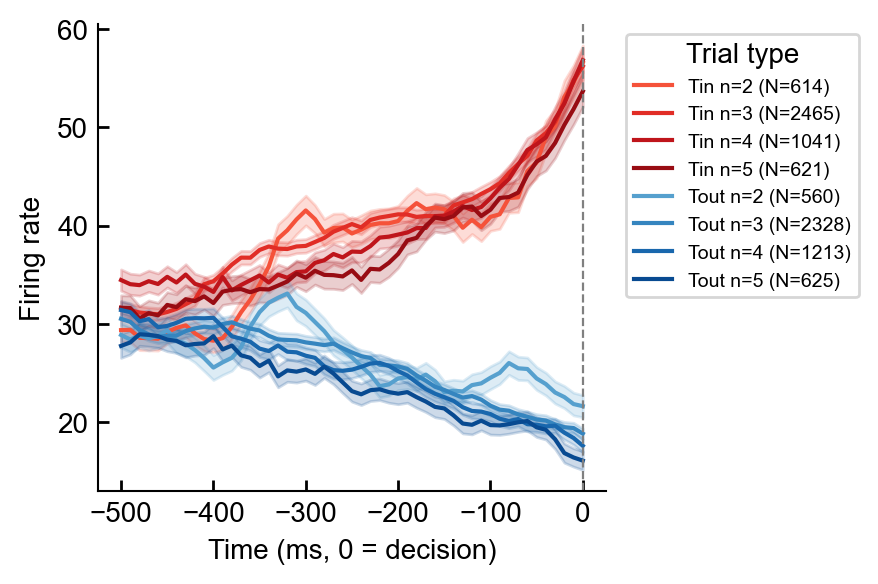

In [13]:
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
FM_aligned = FM[~mask_bad_fr.values]

n_pre = 50  # 400ms before decision
window_bins = n_pre + 1  # include decision
time_ms = np.arange(-n_pre * 10, 1, 10)  # -500..0 if n_pre=50 => -500? (here -500ms); with 10ms/bin

# Extract rt-aligned traces for each trial
traces = []
valid_rt = []
for i in range(len(data)):
    rt_ms = data.iloc[i]["rt"]
    col_at_rt = int(rt_ms / 10)
    col_start = col_at_rt - n_pre
    if col_start < 0:
        valid_rt.append(False)
        traces.append(np.full(window_bins, np.nan))
        continue
    valid_rt.append(True)
    col_end = col_at_rt + 1
    traces.append(FM_aligned[i, col_start:col_end])

data["rt_aligned_trace"] = traces
data["rt_aligned_valid"] = valid_rt

# Filter valid trials (rt >= 400ms for full window)
df_rt = data[data["rt_aligned_valid"]].copy()
df_rt = df_rt.dropna(subset=["TinOrTout", "nums_shape"]).copy()

# 只保留 nums_shape = 3,4,5
df_rt = df_rt[df_rt["nums_shape"].isin([1, 2, 3, 4, 5])].copy()

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

levels = [1, 2, 3, 4, 5]

# Tin 用 Reds，Tout 用 Blues，每个 level 一个深浅
reds = cm.get_cmap("Reds")(np.linspace(0.45, 0.9, len(levels)))
blues = cm.get_cmap("Blues")(np.linspace(0.45, 0.9, len(levels)))
color_map = {("Tin", lv): reds[i] for i, lv in enumerate(levels)}
color_map.update({("Tout", lv): blues[i] for i, lv in enumerate(levels)})

plt.figure(figsize=(4.5, 3))
for tinout_val, label in [(1.0, "Tin"), (2.0, "Tout")]:
    sub = df_rt[df_rt["TinOrTout"] == tinout_val]
    for lv in levels:
        sub_n = sub[sub["nums_shape"] == lv]
        if len(sub_n) < 1:
            continue

        arr = np.stack(sub_n["rt_aligned_trace"].values)  # (n_trials, window_bins)
        mean_trace = np.nanmean(arr, axis=0)
        sem_trace = np.nanstd(arr, axis=0) / np.sqrt(len(sub_n))

        c = color_map[(label, lv)]
        plt.plot(time_ms, mean_trace, color=c, label=f"{label} n={lv} (N={len(sub_n)})")
        plt.fill_between(time_ms, mean_trace - sem_trace, mean_trace + sem_trace, color=c, alpha=0.2)

plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Time (ms, 0 = decision)")
plt.ylabel("Firing rate")
plt.legend(title="Trial type", fontsize=7, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [15]:
np.shape(data2)

NameError: name 'data2' is not defined

/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10683/772030880.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10683/772030880.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10683/772030880.py:167: RuntimeWarning: Mean of empty slice
  mean_fr = np.nanmean(traces, axis=0)
/Users/lijialin/miniconda3/envs/deeprl/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2035: Runt

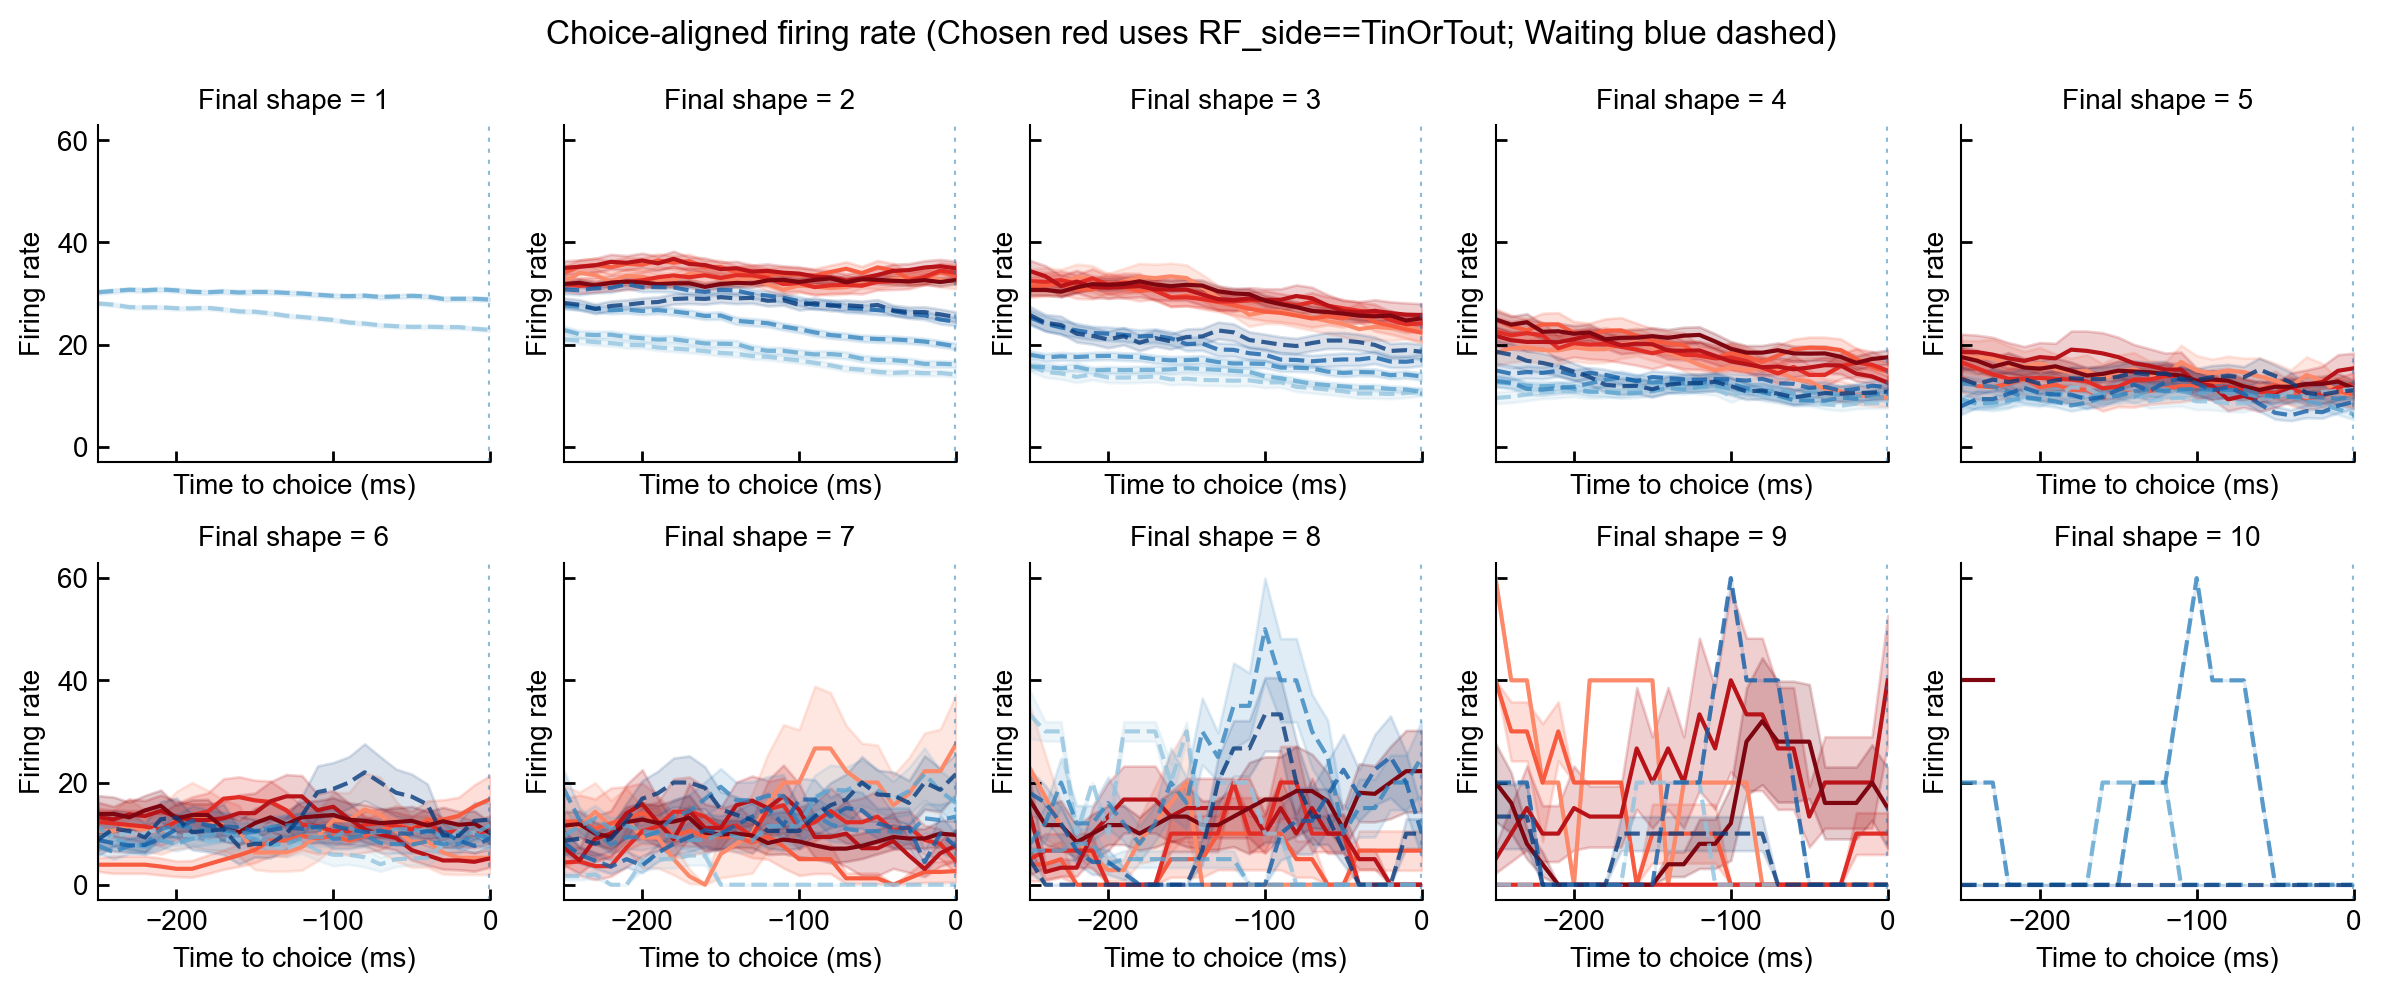

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# 0) 参数
# -----------------------------
bin_ms = 10
bins_per_shape = 25  # 250ms
n_pre = 25           # 40 bins = 400ms before choice
n_post = 0           # 只画到choice时刻；如果你想画choice后，加比如 20 (=200ms)

t_rel = np.arange(-n_pre*bin_ms, (n_post+1)*bin_ms, bin_ms)  # -400..0 (or more)

n_bins = 5
logLR_table = np.array([np.inf, -np.inf, 0.9, -0.9, 0.7, -0.7, 0.5, -0.5, 0.3, -0.3])

# -----------------------------
# 1) 同步过滤：保证 data 与 FM 行对齐
# -----------------------------
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
good_mask = ~mask_bad_fr.values

data2 = data.loc[good_mask].copy().reset_index(drop=True)
FM2 = FM[good_mask]  # 现在 FM2[i] 与 data2.iloc[i] 同一个trial

# -----------------------------
# 2) 计算每个 trial 的 partial cum_loglr（用于 waiting 分箱）
# -----------------------------
shape_vals = data2.iloc[:, 10:30].to_numpy()
valid_mask = ~np.isnan(shape_vals)

partial_cum = np.full((len(data2), 20), np.nan)
for i in range(len(data2)):
    ids = shape_vals[i, valid_mask[i]].astype(int)
    for k in range(1, 11):
        if k <= len(ids):
            partial_cum[i, k] = np.sum(logLR_table[ids[:k]])

k_final = data2["nums_shape"].astype(int).to_numpy()
last_dur = data2["last_duration"].to_numpy()

# last_duration -> bin index within final shape
last_bin = np.floor(last_dur / bin_ms).astype(int)
last_bin = np.clip(last_bin, 0, bins_per_shape - 1) 

choice_col = (k_final - 1) * bins_per_shape + last_bin 

traces_choice = np.full((len(data2), n_pre + n_post + 1), np.nan)
valid_choice = np.zeros(len(data2), dtype=bool)

for i in range(len(data2)):
    cc = int(choice_col[i])
    start = cc - n_pre
    end = cc + n_post + 1  # python右开
    if start >= 0 and end <= FM2.shape[1]:
        traces_choice[i, :] = FM2[i, start:end]
        valid_choice[i] = True

data2["valid_choice_align"] = valid_choice

reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))

fig, axes = plt.subplots(2, 5, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

df_plot = data2[
    (data2["nums_shape"] >= 1) & (data2["nums_shape"] <= 20) &
    np.isfinite(data2["cum_loglr"]) &
    data2["valid_choice_align"]
].copy()

for k in range(1, 11):
    ax = axes[k - 1]

    chosen_lr = df_plot.loc[df_plot["nums_shape"] == k, "cum_loglr"].values

    wait_idx = df_plot.index[df_plot["nums_shape"] > k]
    wait_lr = partial_cum[wait_idx, k]

    all_lr = np.concatenate([
        np.abs(chosen_lr[np.isfinite(chosen_lr)]),
        np.abs(wait_lr[np.isfinite(wait_lr)])
    ])

    if len(all_lr) < n_bins * 2:
        bin_edges_k = np.array([0, np.percentile(all_lr, 50), np.max(all_lr) + 0.01]) if len(all_lr) > 0 else np.array([0, 1])
    else:
        bin_edges_k = np.percentile(all_lr, np.linspace(0, 100, n_bins + 1))
        bin_edges_k = np.unique(bin_edges_k)
        if len(bin_edges_k) < 2:
            bin_edges_k = np.array([0, np.max(all_lr) + 0.01])

    # ---- Chosen (red): nums_shape==k 且 RF_side==TinOrTout
    chosen_sub = df_plot[
        (df_plot["nums_shape"] == k) &
        (df_plot["RF_side"] == df_plot["TinOrTout"])
    ]

    abs_chosen = np.abs(chosen_sub["cum_loglr"].values)

    for b in range(min(n_bins, len(bin_edges_k) - 1)):
        lo, hi = bin_edges_k[b], bin_edges_k[b + 1]
        if b < len(bin_edges_k) - 2:
            sel = (abs_chosen >= lo) & (abs_chosen < hi)
        else:
            sel = (abs_chosen >= lo)

        sub = chosen_sub.loc[sel]
        if len(sub) < 2:
            continue

        idxs = sub.index.to_numpy()
        traces = traces_choice[idxs, :]
        if traces.shape[0] < 2:
            continue

        mean_fr = np.nanmean(traces, axis=0)
        sem_fr = np.nanstd(traces, axis=0) / np.sqrt(traces.shape[0])
        lr_mid = np.nanmean(abs_chosen[sel])

        ax.plot(t_rel, mean_fr, color=reds[b], label=f"Chosen |LR|≈{lr_mid:.2f}")
        ax.fill_between(t_rel, mean_fr - sem_fr, mean_fr + sem_fr, color=reds[b], alpha=0.2)

    # ---- Waiting (blue): nums_shape>k，按 |partial_cum(k)| 分箱
    wait_mask = df_plot["nums_shape"] > k
    if np.sum(wait_mask) >= 5:
        data_idx = df_plot.index[wait_mask]
        partial_k = partial_cum[data_idx, k]
        abs_partial = np.abs(partial_k)
        valid_partial = np.isfinite(abs_partial)

        for b in range(min(n_bins, len(bin_edges_k) - 1)):
            lo, hi = bin_edges_k[b], bin_edges_k[b + 1]
            if b < len(bin_edges_k) - 2:
                sel = valid_partial & (abs_partial >= lo) & (abs_partial < hi)
            else:
                sel = valid_partial & (abs_partial >= lo)

            rows = data_idx[sel]
            if len(rows) < 2:
                continue

            traces = traces_choice[rows.to_numpy(), :]  # 注意：waiting也按它们“自己的choice时刻”对齐
            if traces.shape[0] < 2:
                continue

            mean_fr = np.nanmean(traces, axis=0)
            sem_fr = np.nanstd(traces, axis=0) / np.sqrt(traces.shape[0])
            lr_mid = np.nanmean(abs_partial[sel])

            ax.plot(t_rel, mean_fr, color=blues[b], linestyle="--", alpha=0.8,
                    label=f"Wait |LR|≈{lr_mid:.2f}")
            ax.fill_between(t_rel, mean_fr - sem_fr, mean_fr + sem_fr, color=blues[b], alpha=0.15)

    ax.set_title(f"Final shape = {k}")
    ax.set_xlabel("Time to choice (ms)")
    ax.set_ylabel("Firing rate")
    ax.axvline(0, linestyle=":", alpha=0.5)  # choice moment
    ax.set_xlim(t_rel[0], t_rel[-1])

plt.suptitle("Choice-aligned firing rate (Chosen red uses RF_side==TinOrTout; Waiting blue dashed)")
plt.tight_layout()
plt.show()